In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [4]:
# Load dataset
df = pd.read_csv('Mall_Customers.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Basic Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


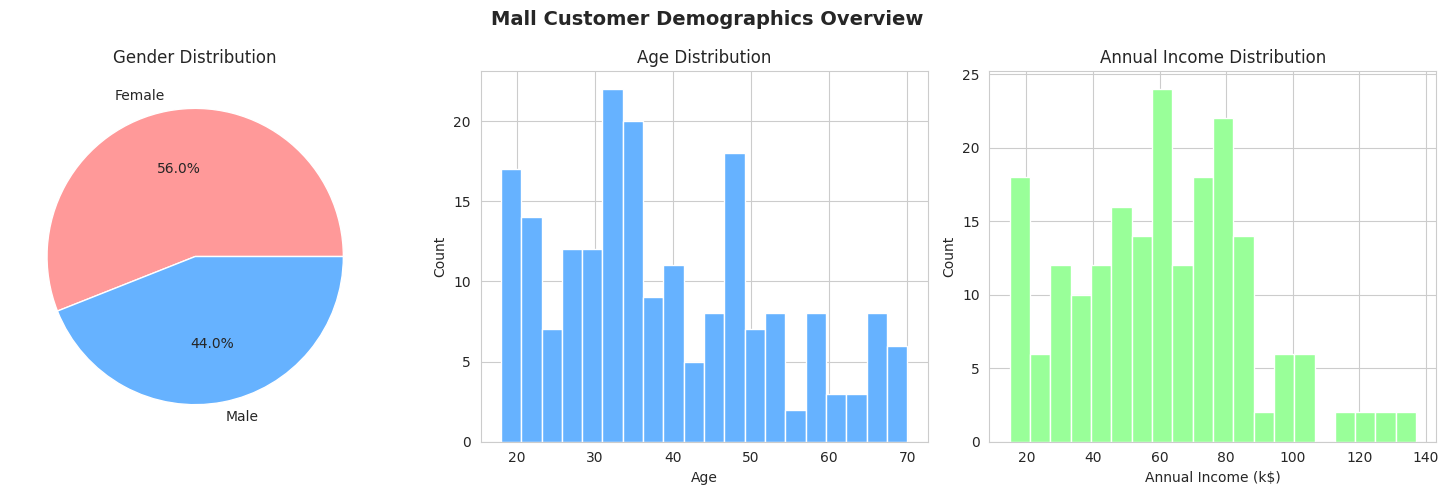

Chart saved!


In [5]:
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Mall Customer Demographics Overview', fontsize=14, fontweight='bold')

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#FF9999','#66B2FF'])
axes[0].set_title('Gender Distribution')

# Age distribution
axes[1].hist(df['Age'], bins=20, color='#66B2FF', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# Income distribution
axes[2].hist(df['Annual Income (k$)'], bins=20, color='#99FF99', edgecolor='white')
axes[2].set_title('Annual Income Distribution')
axes[2].set_xlabel('Annual Income (k$)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('demographics_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

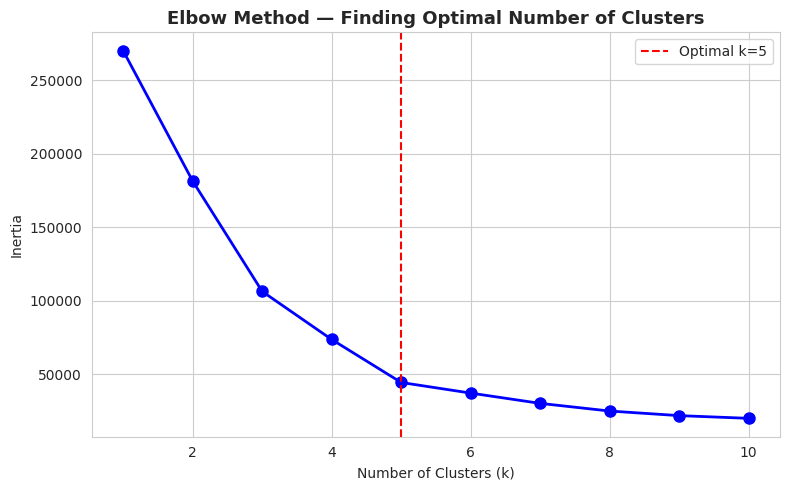

Optimal number of clusters: 5


In [6]:
# Use Income and Spending Score for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Find optimal clusters using Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', label='Optimal k=5')
plt.title('Elbow Method — Finding Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Optimal number of clusters: 5")

In [7]:
# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Name the segments based on income/spending behavior
segment_names = {
    0: 'Unknown',  # we'll identify these below
    1: 'Unknown',
    2: 'Unknown',
    3: 'Unknown',
    4: 'Unknown'
}

# Analyze cluster centers to name them
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
}).round(1)
cluster_summary.columns = ['Avg_Income', 'Avg_Spending', 'Avg_Age', 'Count']
cluster_summary = cluster_summary.sort_values('Avg_Income')

print("Cluster Centers:")
display(cluster_summary)

Cluster Centers:


,Avg_Income,Avg_Spending,Avg_Age,Count
Cluster,,,,
2,25.7,79.4,25.3,22
4,26.3,20.9,45.2,23
0,55.3,49.5,42.7,81
1,86.5,82.1,32.7,39
3,88.2,17.1,41.1,35


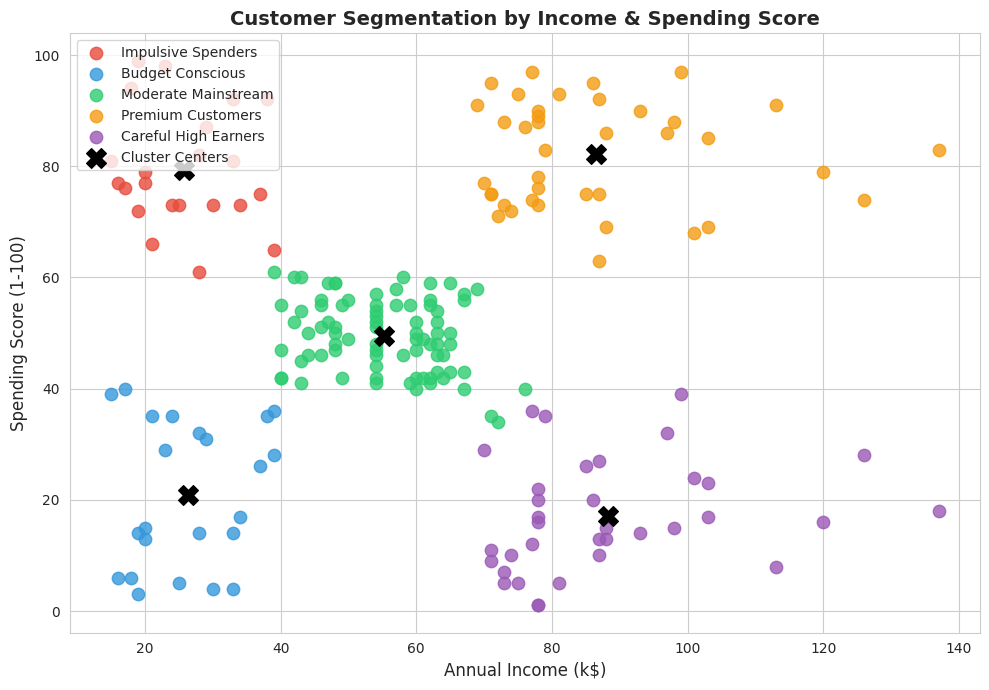

Segmentation chart saved!


In [8]:
# Map clusters to meaningful segment names
# Based on income vs spending pattern
cluster_labels = {}
for idx, row in cluster_summary.iterrows():
    income = row['Avg_Income']
    spending = row['Avg_Spending']
    if income < 40 and spending < 50:
        cluster_labels[idx] = 'Budget Conscious'
    elif income < 40 and spending > 50:
        cluster_labels[idx] = 'Impulsive Spenders'
    elif income > 60 and spending > 60:
        cluster_labels[idx] = 'Premium Customers'
    elif income > 60 and spending < 50:
        cluster_labels[idx] = 'Careful High Earners'
    else:
        cluster_labels[idx] = 'Moderate Mainstream'

df['Segment'] = df['Cluster'].map(cluster_labels)

# Visualize the segments
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
plt.figure(figsize=(10, 7))

for i, (cluster_id, segment_name) in enumerate(cluster_labels.items()):
    mask = df['Cluster'] == cluster_id
    plt.scatter(df[mask]['Annual Income (k$)'],
                df[mask]['Spending Score (1-100)'],
                c=colors[i], label=segment_name, s=80, alpha=0.8)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Cluster Centers')

plt.title('Customer Segmentation by Income & Spending Score',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Segmentation chart saved!")

In [9]:
# Final business summary
print("=" * 55)
print("   CUSTOMER SEGMENTATION — BUSINESS SUMMARY")
print("=" * 55)

segment_analysis = df.groupby('Segment').agg({
    'CustomerID': 'count',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean'
}).round(1)
segment_analysis.columns = ['Count', 'Avg_Income_k', 'Avg_Spending_Score', 'Avg_Age']
segment_analysis['Pct_of_Customers'] = (segment_analysis['Count'] / len(df) * 100).round(1)

display(segment_analysis)

print("\n📋 MARKETING RECOMMENDATIONS:")
print("-" * 55)
print("🟢 Premium Customers   → VIP loyalty program, premium offers")
print("🔵 Careful High Earners → Educate on value, build trust first")
print("🟡 Moderate Mainstream → Upsell bundles, mid-range promotions")
print("🟠 Impulsive Spenders  → Flash sales, limited-time offers")
print("🔴 Budget Conscious    → Discounts, value packs, clearance")

   CUSTOMER SEGMENTATION — BUSINESS SUMMARY


,Count,Avg_Income_k,Avg_Spending_Score,Avg_Age,Pct_of_Customers
Segment,,,,,
Budget Conscious,23,26.3,20.9,45.2,11.5
Careful High Earners,35,88.2,17.1,41.1,17.5
Impulsive Spenders,22,25.7,79.4,25.3,11.0
Moderate Mainstream,81,55.3,49.5,42.7,40.5
Premium Customers,39,86.5,82.1,32.7,19.5



📋 MARKETING RECOMMENDATIONS:
-------------------------------------------------------
🟢 Premium Customers   → VIP loyalty program, premium offers
🔵 Careful High Earners → Educate on value, build trust first
🟡 Moderate Mainstream → Upsell bundles, mid-range promotions
🟠 Impulsive Spenders  → Flash sales, limited-time offers
🔴 Budget Conscious    → Discounts, value packs, clearance


<Figure size 1000x500 with 0 Axes>

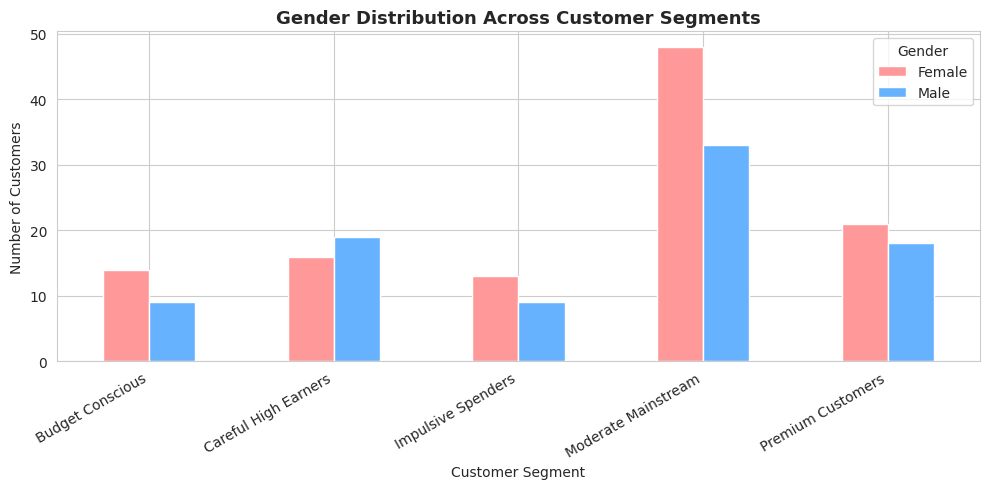

Gender analysis saved!


In [10]:
# Gender breakdown per segment
plt.figure(figsize=(10, 5))
gender_segment = df.groupby(['Segment', 'Gender']).size().unstack()
gender_segment.plot(kind='bar', color=['#FF9999', '#66B2FF'],
                    edgecolor='white', figsize=(10,5))
plt.title('Gender Distribution Across Customer Segments',
          fontsize=13, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('gender_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gender analysis saved!")

In [12]:
# I first tried clustering with 3 variables (Age, Income, Spending)
# but the segments were less distinct — removing Age gave cleaner results
# See elbow curve comparison below